# MLOps with Weights & Biases

This notebook shows a practical experiment-tracking workflow with [Weights & Biases](https://wandb.ai/site), often shortened to W&B. We will use a small `scikit-learn` dataset so the machine learning part stays familiar while the focus stays on MLOps:

- creating a W&B account and logging in;
- logging a dataset artifact;
- running several training jobs with configs, metrics, tables, charts, and model artifacts;
- comparing runs in the W&B UI.

The examples use the Breast Cancer Wisconsin Diagnostic dataset bundled with `scikit-learn`. No external dataset download is required.


## 0. Create a W&B Account and Log In

Before running the logging cells in online mode:

1. Open [wandb.ai/site](https://wandb.ai/site) and create a free W&B account. Use a personal or school email that you can access during class.
2. After signing in, open [wandb.ai/authorize](https://wandb.ai/authorize) or your W&B user settings page to find your API key. Treat this key like a password. Do not commit it to GitHub or paste it into shared notebooks.
3. Install the project requirements and this topic's W&B dependency if you have not already done that:

```bash
python -m pip install -r requirements.txt
python -m pip install -r "Topic 14. MLOps/requirements-mlops.txt"
```

4. Log in from a terminal:

```bash
wandb login
```

You can also let the notebook login cell call `wandb.login()` and paste the API key there when prompted.

Useful modes while learning:

- `WANDB_MODE=online`: send runs to the W&B cloud project. This is the mode that changes the UI immediately.
- `WANDB_MODE=offline`: save runs locally first, then sync later with `wandb sync wandb/offline-run-*`.
- `WANDB_MODE=disabled`: run the notebook without creating W&B runs. This is useful for dry runs and automated validation.

After the first logging cell finishes, open [wandb.ai/home](https://wandb.ai/home), choose your project, and keep the W&B UI open in another browser tab while you run the rest of the notebook.


## 1. What to Watch in the W&B UI

As you run the notebook, pause after each major section and inspect these W&B pages:

- **Runs**: each call to `wandb.init()` creates a run. Add columns such as `config/model_type`, `test/roc_auc`, and `test/f1`.
- **Charts**: metrics logged over time become line charts automatically. Images logged with `wandb.Image` appear as visual panels.
- **Tables**: prediction examples logged with `wandb.Table` can be filtered and sorted in the browser.
- **Artifacts**: datasets and models show up as versioned objects. Open an artifact to inspect files, metadata, and lineage.

The goal is not just to save numbers. The goal is to make experiment history visible, reproducible, and easier to compare.


In [ ]:
import json
import os
import tempfile
import warnings
from pathlib import Path

os.environ.setdefault("MPLCONFIGDIR", tempfile.gettempdir())
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

try:
    import wandb
except ImportError as exc:
    raise ImportError(
        "This notebook uses Weights & Biases. Install the Topic 14 requirements with "
        "`python -m pip install -r \"Topic 14. MLOps/requirements-mlops.txt\"`, then run the notebook again."
    ) from exc

from sklearn.datasets import load_breast_cancer
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    log_loss,
    precision_score,
    recall_score,
    roc_auc_score,
    roc_curve,
)
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.svm import SVC

warnings.filterwarnings("ignore", category=FutureWarning)

RANDOM_STATE = 42
WANDB_PROJECT = os.getenv("WANDB_PROJECT", "ml-fundamentals-topic-14-mlops")
WANDB_ENTITY = os.getenv("WANDB_ENTITY") or None
WANDB_MODE = os.getenv("WANDB_MODE", "online").strip().lower()
VALID_WANDB_MODES = {"online", "offline", "disabled"}

if WANDB_MODE not in VALID_WANDB_MODES:
    raise ValueError(f"WANDB_MODE must be one of {sorted(VALID_WANDB_MODES)}, got {WANDB_MODE!r}")

ARTIFACT_DIR = Path("wandb_local_artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

plt.rcParams.update({
    "figure.figsize": (8, 5),
    "axes.grid": True,
    "grid.alpha": 0.25,
})

print(f"W&B project: {WANDB_PROJECT}")
print(f"W&B entity: {WANDB_ENTITY or '(default account/team)'}")
print(f"W&B mode: {WANDB_MODE}")


In [ ]:
if WANDB_MODE == "online":
    wandb.login()
elif WANDB_MODE == "offline":
    print("Offline mode: runs will be written locally. Sync later with `wandb sync wandb/offline-run-*`.")
else:
    print("Disabled mode: code will run without creating W&B runs or prompts.")


## 2. Load a Small Classification Dataset

We will work with the Breast Cancer Wisconsin Diagnostic dataset. The target has two classes:

- `malignant`
- `benign`

The dataset is small enough for fast classroom runs, but realistic enough to compare models, probabilities, ROC AUC, confusion matrices, and feature effects.


In [3]:
raw = load_breast_cancer(as_frame=True)
X = raw.data.copy()
y = raw.target.copy()

TARGET_NAMES = {index: name for index, name in enumerate(raw.target_names)}
FEATURE_NAMES = X.columns.tolist()

full_data = X.copy()
full_data["target"] = y
full_data["diagnosis"] = y.map(TARGET_NAMES)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.25,
    stratify=y,
    random_state=RANDOM_STATE,
)

class_balance = (
    full_data["diagnosis"]
    .value_counts(normalize=True)
    .rename("share")
    .mul(100)
    .round(2)
    .to_frame()
)

split_summary = pd.DataFrame({
    "split": ["train", "test"],
    "rows": [len(X_train), len(X_test)],
    "benign_rate": [float(y_train.mean()), float(y_test.mean())],
})

display(split_summary)
display(class_balance)
full_data.head()


,split,rows,benign_rate
0,train,426,0.626761
1,test,143,0.629371


,share
diagnosis,
benign,62.74
malignant,37.26


,mean radius,mean texture,mean perimeter,mean area,mean smoothness,mean compactness,mean concavity,mean concave points,mean symmetry,mean fractal dimension,...,worst perimeter,worst area,worst smoothness,worst compactness,worst concavity,worst concave points,worst symmetry,worst fractal dimension,target,diagnosis
0,17.99,10.38,122.80,1001.0,0.11840,0.27760,0.3001,0.14710,0.2419,0.07871,...,184.60,2019.0,0.1622,0.6656,0.7119,0.2654,0.4601,0.11890,0,malignant
1,20.57,17.77,132.90,1326.0,0.08474,0.07864,0.0869,0.07017,0.1812,0.05667,...,158.80,1956.0,0.1238,0.1866,0.2416,0.1860,0.2750,0.08902,0,malignant
2,19.69,21.25,130.00,1203.0,0.10960,0.15990,0.1974,0.12790,0.2069,0.05999,...,152.50,1709.0,0.1444,0.4245,0.4504,0.2430,0.3613,0.08758,0,malignant
3,11.42,20.38,77.58,386.1,0.14250,0.28390,0.2414,0.10520,0.2597,0.09744,...,98.87,567.7,0.2098,0.8663,0.6869,0.2575,0.6638,0.17300,0,malignant
4,20.29,14.34,135.10,1297.0,0.10030,0.13280,0.1980,0.10430,0.1809,0.05883,...,152.20,1575.0,0.1374,0.2050,0.4000,0.1625,0.2364,0.07678,0,malignant


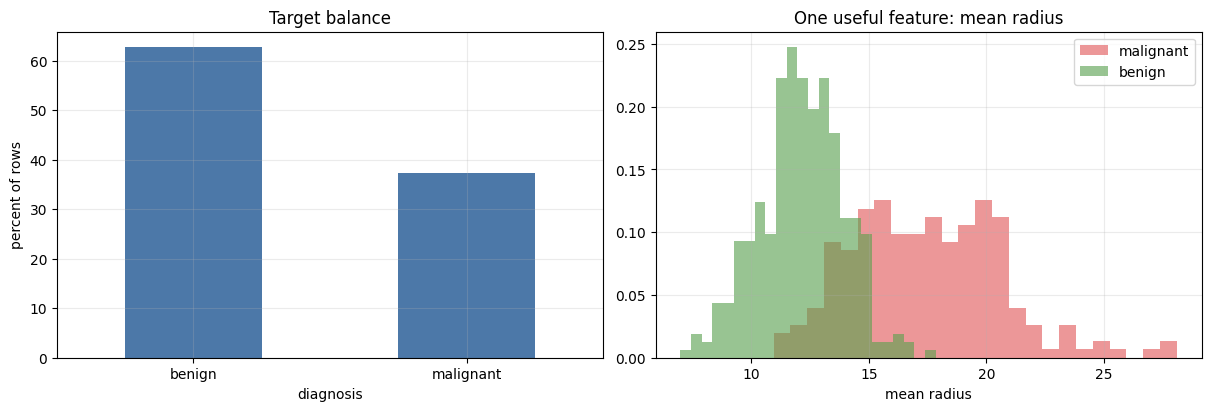

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

class_balance.sort_index().plot(kind="bar", ax=axes[0], legend=False, color="#4C78A8")
axes[0].set_title("Target balance")
axes[0].set_ylabel("percent of rows")
axes[0].tick_params(axis="x", rotation=0)

for target_value, target_name, color in [
    (0, TARGET_NAMES[0], "#E15759"),
    (1, TARGET_NAMES[1], "#59A14F"),
]:
    subset = full_data.loc[full_data["target"] == target_value, "mean radius"]
    axes[1].hist(subset, bins=24, alpha=0.62, density=True, label=target_name, color=color)

axes[1].set_title("One useful feature: mean radius")
axes[1].set_xlabel("mean radius")
axes[1].legend(frameon=True)

plt.show()


## 3. Log the Dataset as a W&B Artifact

A dataset artifact gives the training runs something concrete to point back to. In a production workflow, this is how you answer questions such as:

- Which data split trained this model?
- Did a later model use the same dataset version?
- What files and metadata were attached to the dataset?

Run the next cell, then open the W&B UI and inspect **Artifacts**. You should see a dataset artifact with CSV files and metadata.


In [ ]:
dataset_dir = ARTIFACT_DIR / "breast_cancer_dataset"
dataset_dir.mkdir(parents=True, exist_ok=True)

train_export = X_train.copy()
train_export["target"] = y_train
train_export["diagnosis"] = y_train.map(TARGET_NAMES)

test_export = X_test.copy()
test_export["target"] = y_test
test_export["diagnosis"] = y_test.map(TARGET_NAMES)

train_path = dataset_dir / "train.csv"
test_path = dataset_dir / "test.csv"
metadata_path = dataset_dir / "metadata.json"

train_export.to_csv(train_path, index=False)
test_export.to_csv(test_path, index=False)

dataset_metadata = {
    "source": "sklearn.datasets.load_breast_cancer",
    "rows": int(len(full_data)),
    "features": int(X.shape[1]),
    "train_rows": int(len(train_export)),
    "test_rows": int(len(test_export)),
    "target_names": TARGET_NAMES,
    "random_state": RANDOM_STATE,
}

metadata_path.write_text(json.dumps(dataset_metadata, indent=2), encoding="utf-8")

run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name="log-sklearn-breast-cancer-dataset",
    job_type="dataset",
    tags=["topic-14", "dataset", "sklearn"],
    config=dataset_metadata,
    mode=WANDB_MODE,
    reinit=True,
)

try:
    sample_table = wandb.Table(dataframe=full_data.sample(40, random_state=RANDOM_STATE))
    balance_for_wandb = class_balance.reset_index()
    balance_for_wandb.columns = ["diagnosis", "share"]
    balance_table = wandb.Table(dataframe=balance_for_wandb)

    run.log({
        "dataset/sample_rows": sample_table,
        "dataset/class_balance": balance_table,
    })

    dataset_artifact = wandb.Artifact(
        name="breast-cancer-sklearn-split",
        type="dataset",
        description="Train/test split of sklearn's Breast Cancer Wisconsin Diagnostic dataset.",
        metadata=dataset_metadata,
    )
    dataset_artifact.add_file(str(train_path))
    dataset_artifact.add_file(str(test_path))
    dataset_artifact.add_file(str(metadata_path))
    run.log_artifact(dataset_artifact)
finally:
    run.finish()

print(f"Wrote local dataset files to: {dataset_dir.resolve()}")


## 4. Helper Functions for Metrics, Charts, Tables, and Models

The next helpers keep the W&B logging code consistent across runs. Each training run will log:

- a config dictionary that records modeling choices;
- scalar test metrics;
- a prediction table;
- confusion matrix, ROC curve, and probability charts;
- a serialized model artifact.


In [6]:
def probability_matrix(y_proba_positive):
    y_proba_positive = np.asarray(y_proba_positive)
    return np.column_stack([1 - y_proba_positive, y_proba_positive])


def evaluate_binary_classifier(y_true, y_pred, y_proba_positive):
    proba_matrix = probability_matrix(y_proba_positive)
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "balanced_accuracy": balanced_accuracy_score(y_true, y_pred),
        "precision": precision_score(y_true, y_pred),
        "recall": recall_score(y_true, y_pred),
        "f1": f1_score(y_true, y_pred),
        "roc_auc": roc_auc_score(y_true, y_proba_positive),
        "log_loss": log_loss(y_true, proba_matrix, labels=[0, 1]),
    }


def prediction_table(X_values, y_true, y_pred, y_proba_positive, max_rows=120):
    rows = X_values.copy().reset_index(drop=True)
    true_values = pd.Series(y_true).reset_index(drop=True)
    pred_values = pd.Series(y_pred).reset_index(drop=True)

    rows.insert(0, "actual", true_values.map(TARGET_NAMES))
    rows.insert(1, "predicted", pred_values.map(TARGET_NAMES))
    rows.insert(2, "probability_benign", np.round(y_proba_positive, 4))
    rows.insert(3, "is_correct", true_values.eq(pred_values))

    return rows.head(max_rows)


def confusion_matrix_figure(y_true, y_pred, title):
    fig, ax = plt.subplots(figsize=(5.5, 4.8), constrained_layout=True)
    ConfusionMatrixDisplay.from_predictions(
        y_true,
        y_pred,
        display_labels=[TARGET_NAMES[0], TARGET_NAMES[1]],
        cmap="Blues",
        values_format="d",
        ax=ax,
        colorbar=False,
    )
    ax.set_title(title)
    return fig


def roc_curve_figure(y_true, y_proba_positive, title):
    fpr, tpr, _ = roc_curve(y_true, y_proba_positive)
    auc_value = roc_auc_score(y_true, y_proba_positive)

    fig, ax = plt.subplots(figsize=(5.8, 4.8), constrained_layout=True)
    ax.plot(fpr, tpr, color="#4C78A8", linewidth=2.5, label=f"ROC AUC = {auc_value:.3f}")
    ax.plot([0, 1], [0, 1], linestyle="--", color="#9E9E9E", label="random")
    ax.set_xlabel("False positive rate")
    ax.set_ylabel("True positive rate")
    ax.set_title(title)
    ax.legend(frameon=True)
    return fig


def probability_histogram_figure(y_true, y_proba_positive, title):
    fig, ax = plt.subplots(figsize=(6.2, 4.6), constrained_layout=True)

    for target_value, color in [(0, "#E15759"), (1, "#59A14F")]:
        mask = np.asarray(y_true) == target_value
        ax.hist(
            np.asarray(y_proba_positive)[mask],
            bins=np.linspace(0, 1, 21),
            alpha=0.68,
            density=True,
            color=color,
            label=f"actual {TARGET_NAMES[target_value]}",
        )

    ax.set_xlabel("Predicted probability of benign")
    ax.set_ylabel("Density")
    ax.set_title(title)
    ax.legend(frameon=True)
    return fig


def model_feature_frame(fitted_model, run_name, max_features=15):
    if hasattr(fitted_model, "named_steps"):
        estimator = fitted_model.named_steps.get("model", fitted_model)
    else:
        estimator = fitted_model

    if hasattr(estimator, "coef_"):
        values = estimator.coef_[0]
        frame = pd.DataFrame({
            "feature": FEATURE_NAMES,
            "value": values,
            "importance_type": "coefficient",
            "run_name": run_name,
        })
        frame["abs_value"] = frame["value"].abs()
        return frame.sort_values("abs_value", ascending=False).head(max_features)

    if hasattr(estimator, "feature_importances_"):
        frame = pd.DataFrame({
            "feature": FEATURE_NAMES,
            "value": estimator.feature_importances_,
            "importance_type": "feature_importance",
            "run_name": run_name,
        })
        frame["abs_value"] = frame["value"].abs()
        return frame.sort_values("abs_value", ascending=False).head(max_features)

    return pd.DataFrame(columns=["feature", "value", "importance_type", "run_name", "abs_value"])


def feature_chart_figure(feature_frame, title):
    if feature_frame.empty:
        return None

    plot_frame = feature_frame.sort_values("abs_value", ascending=True)
    fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
    colors = np.where(plot_frame["value"] >= 0, "#59A14F", "#E15759")
    ax.barh(plot_frame["feature"], plot_frame["value"], color=colors, alpha=0.86)
    ax.axvline(0, color="#555555", linewidth=1)
    ax.set_title(title)
    ax.set_xlabel(plot_frame["importance_type"].iloc[0])
    return fig


def log_model_outputs(run, fitted_model, run_name, config, metrics):
    y_pred = fitted_model.predict(X_test)
    y_proba_positive = fitted_model.predict_proba(X_test)[:, 1]

    predictions = prediction_table(X_test, y_test, y_pred, y_proba_positive)
    feature_frame = model_feature_frame(fitted_model, run_name)

    cm_fig = confusion_matrix_figure(y_test, y_pred, f"{run_name}: confusion matrix")
    roc_fig = roc_curve_figure(y_test, y_proba_positive, f"{run_name}: ROC curve")
    hist_fig = probability_histogram_figure(y_test, y_proba_positive, f"{run_name}: probability distribution")
    feature_fig = feature_chart_figure(feature_frame, f"{run_name}: top features")

    log_payload = {
        "predictions/test_examples": wandb.Table(dataframe=predictions),
        "charts/confusion_matrix": wandb.Image(cm_fig),
        "charts/roc_curve": wandb.Image(roc_fig),
        "charts/probability_histogram": wandb.Image(hist_fig),
    }

    if not feature_frame.empty:
        log_payload["model/top_features"] = wandb.Table(dataframe=feature_frame.drop(columns="abs_value"))

    if feature_fig is not None:
        log_payload["charts/top_features"] = wandb.Image(feature_fig)

    run.log(log_payload)

    for fig in [cm_fig, roc_fig, hist_fig, feature_fig]:
        if fig is not None:
            plt.close(fig)

    model_dir = ARTIFACT_DIR / "models"
    model_dir.mkdir(parents=True, exist_ok=True)
    model_path = model_dir / f"{run_name}.joblib"
    joblib.dump(fitted_model, model_path)

    model_artifact = wandb.Artifact(
        name=f"{run_name}-model",
        type="model",
        description=f"Serialized sklearn model for run {run_name}.",
        metadata={**config, **{f"test_{key}": float(value) for key, value in metrics.items()}},
    )
    model_artifact.add_file(str(model_path))
    run.log_artifact(model_artifact)

    return predictions, feature_frame


## 5. A Training Run with Metrics Over Time

Many W&B examples shine when metrics change over training steps. `SGDClassifier` supports `partial_fit`, so we can simulate epochs and log train/test metrics after each pass through the data.

Run the next cell, then open the W&B run and look at the line charts for:

- `train/log_loss`
- `test/log_loss`
- `test/roc_auc`
- `test/f1`

This is the kind of chart you would inspect when deciding whether training is still improving or starting to plateau.


In [ ]:
sgd_config = {
    "model_type": "SGDClassifier",
    "loss": "log_loss",
    "penalty": "elasticnet",
    "alpha": 0.0005,
    "l1_ratio": 0.15,
    "epochs": 25,
    "dataset_artifact": "breast-cancer-sklearn-split",
    "random_state": RANDOM_STATE,
}

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
y_train_array = y_train.to_numpy()
y_test_array = y_test.to_numpy()
classes = np.array([0, 1])

sgd_model = SGDClassifier(
    loss=sgd_config["loss"],
    penalty=sgd_config["penalty"],
    alpha=sgd_config["alpha"],
    l1_ratio=sgd_config["l1_ratio"],
    random_state=RANDOM_STATE,
)

rng = np.random.default_rng(RANDOM_STATE)
history = []

run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name="sgd-log-loss-epochs",
    job_type="train",
    tags=["topic-14", "training-curve", "sgd"],
    config=sgd_config,
    mode=WANDB_MODE,
    reinit=True,
)

try:
    run.define_metric("epoch")
    run.define_metric("train/*", step_metric="epoch")
    run.define_metric("test/*", step_metric="epoch")

    for epoch in range(1, sgd_config["epochs"] + 1):
        order = rng.permutation(len(X_train_scaled))
        sgd_model.partial_fit(X_train_scaled[order], y_train_array[order], classes=classes)

        train_proba = sgd_model.predict_proba(X_train_scaled)[:, 1]
        test_proba = sgd_model.predict_proba(X_test_scaled)[:, 1]
        test_pred = (test_proba >= 0.5).astype(int)

        epoch_metrics = {
            "epoch": epoch,
            "train/log_loss": log_loss(y_train_array, probability_matrix(train_proba), labels=[0, 1]),
            "test/log_loss": log_loss(y_test_array, probability_matrix(test_proba), labels=[0, 1]),
            "test/roc_auc": roc_auc_score(y_test_array, test_proba),
            "test/f1": f1_score(y_test_array, test_pred),
            "test/accuracy": accuracy_score(y_test_array, test_pred),
        }
        history.append(epoch_metrics)
        run.log(epoch_metrics)

    sgd_pipeline = Pipeline([
        ("scaler", scaler),
        ("model", sgd_model),
    ])

    final_pred = sgd_pipeline.predict(X_test)
    final_proba = sgd_pipeline.predict_proba(X_test)[:, 1]
    final_metrics = evaluate_binary_classifier(y_test, final_pred, final_proba)

    run.log({f"test/{key}": value for key, value in final_metrics.items()})
    run.summary["best_test_roc_auc"] = max(item["test/roc_auc"] for item in history)
    run.summary["final_test_f1"] = final_metrics["f1"]

    history_df = pd.DataFrame(history)
    fig, ax = plt.subplots(figsize=(8, 4.8), constrained_layout=True)
    ax.plot(history_df["epoch"], history_df["train/log_loss"], marker="o", label="train log loss")
    ax.plot(history_df["epoch"], history_df["test/log_loss"], marker="o", label="test log loss")
    ax.set_xlabel("epoch")
    ax.set_ylabel("log loss")
    ax.set_title("SGD training curve")
    ax.legend(frameon=True)
    run.log({"charts/training_curve": wandb.Image(fig)})
    plt.show()

    sgd_predictions, sgd_features = log_model_outputs(
        run=run,
        fitted_model=sgd_pipeline,
        run_name="sgd-log-loss-epochs",
        config=sgd_config,
        metrics=final_metrics,
    )
finally:
    run.finish()

display(pd.DataFrame(history).tail())
display(pd.DataFrame([final_metrics]).round(4))


### UI Tip

Open the `sgd-log-loss-epochs` run in W&B. On the run page, compare the automatically created line charts with the logged image chart. Then open **Files** or **Artifacts** and confirm that a `.joblib` model file was logged as a model artifact.


## 6. Log Several Model Runs for Comparison

Now we will launch a small run group with different sklearn models. Each run logs the same metric names, so W&B can compare them in the project table and chart panels.

The configs are intentionally simple:

- logistic regression with different regularization strengths;
- random forest with shallow and deeper trees;
- an RBF support vector classifier.

After the cell finishes, go to the W&B **Runs** page and sort by `test/roc_auc`, `test/f1`, or `test/log_loss`.


In [ ]:
model_specs = [
    (
        "logistic-c-0-1",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(C=0.1, max_iter=2_000, random_state=RANDOM_STATE)),
        ]),
        {"model_type": "LogisticRegression", "C": 0.1, "max_iter": 2_000},
    ),
    (
        "logistic-c-1",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", LogisticRegression(C=1.0, max_iter=2_000, random_state=RANDOM_STATE)),
        ]),
        {"model_type": "LogisticRegression", "C": 1.0, "max_iter": 2_000},
    ),
    (
        "random-forest-depth-3",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=3,
            min_samples_leaf=3,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        {"model_type": "RandomForestClassifier", "n_estimators": 200, "max_depth": 3, "min_samples_leaf": 3},
    ),
    (
        "random-forest-full",
        RandomForestClassifier(
            n_estimators=200,
            max_depth=None,
            min_samples_leaf=1,
            random_state=RANDOM_STATE,
            n_jobs=-1,
        ),
        {"model_type": "RandomForestClassifier", "n_estimators": 200, "max_depth": None, "min_samples_leaf": 1},
    ),
    (
        "svc-rbf",
        Pipeline([
            ("scaler", StandardScaler()),
            ("model", SVC(C=1.5, kernel="rbf", gamma="scale", probability=True, random_state=RANDOM_STATE)),
        ]),
        {"model_type": "SVC", "kernel": "rbf", "C": 1.5, "gamma": "scale", "probability": True},
    ),
]

comparison_rows = []

for run_name, model, model_config in model_specs:
    config = {
        **model_config,
        "dataset": "sklearn_breast_cancer",
        "dataset_artifact": "breast-cancer-sklearn-split",
        "test_size": 0.25,
        "random_state": RANDOM_STATE,
    }

    run = wandb.init(
        project=WANDB_PROJECT,
        entity=WANDB_ENTITY,
        name=run_name,
        job_type="train",
        tags=["topic-14", "model-comparison", model_config["model_type"]],
        group="sklearn-model-comparison",
        config=config,
        mode=WANDB_MODE,
        reinit=True,
    )

    try:
        model.fit(X_train, y_train)
        y_pred = model.predict(X_test)
        y_proba = model.predict_proba(X_test)[:, 1]
        metrics = evaluate_binary_classifier(y_test, y_pred, y_proba)

        run.log({f"test/{key}": value for key, value in metrics.items()})
        run.summary["primary_metric"] = metrics["roc_auc"]

        log_model_outputs(
            run=run,
            fitted_model=model,
            run_name=run_name,
            config=config,
            metrics=metrics,
        )

        comparison_rows.append({
            "run_name": run_name,
            **model_config,
            **metrics,
        })
    finally:
        run.finish()

comparison_df = (
    pd.DataFrame(comparison_rows)
    .sort_values("roc_auc", ascending=False)
    .reset_index(drop=True)
)

display(comparison_df.round(4))


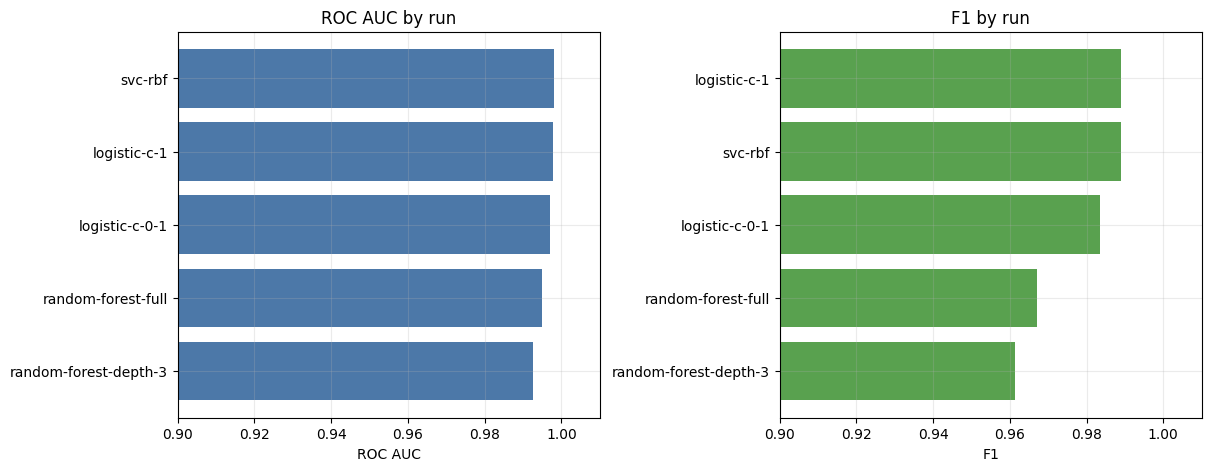

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)

plot_frame = comparison_df.sort_values("roc_auc", ascending=True)
axes[0].barh(plot_frame["run_name"], plot_frame["roc_auc"], color="#4C78A8")
axes[0].set_xlim(0.90, 1.01)
axes[0].set_title("ROC AUC by run")
axes[0].set_xlabel("ROC AUC")

plot_frame = comparison_df.sort_values("f1", ascending=True)
axes[1].barh(plot_frame["run_name"], plot_frame["f1"], color="#59A14F")
axes[1].set_xlim(0.90, 1.01)
axes[1].set_title("F1 by run")
axes[1].set_xlabel("F1")

plt.show()


## 7. Log a Small Analysis Run

The W&B project table already compares individual runs, but it is often useful to log an analysis run that contains a curated summary table and chart. This gives teammates a single run to open when they want the conclusion.


In [ ]:
summary_run = wandb.init(
    project=WANDB_PROJECT,
    entity=WANDB_ENTITY,
    name="model-comparison-summary",
    job_type="analysis",
    tags=["topic-14", "analysis", "comparison"],
    config={
        "models_compared": len(comparison_df),
        "primary_metric": "roc_auc",
        "best_run": comparison_df.iloc[0]["run_name"],
    },
    mode=WANDB_MODE,
    reinit=True,
)

try:
    fig, axes = plt.subplots(1, 2, figsize=(12, 4.6), constrained_layout=True)

    plot_frame = comparison_df.sort_values("roc_auc", ascending=True)
    axes[0].barh(plot_frame["run_name"], plot_frame["roc_auc"], color="#4C78A8")
    axes[0].set_xlim(0.90, 1.01)
    axes[0].set_title("ROC AUC by run")
    axes[0].set_xlabel("ROC AUC")

    plot_frame = comparison_df.sort_values("f1", ascending=True)
    axes[1].barh(plot_frame["run_name"], plot_frame["f1"], color="#59A14F")
    axes[1].set_xlim(0.90, 1.01)
    axes[1].set_title("F1 by run")
    axes[1].set_xlabel("F1")

    summary_run.log({
        "comparison/metrics_table": wandb.Table(dataframe=comparison_df),
        "comparison/metric_bars": wandb.Image(fig),
    })
    plt.close(fig)
finally:
    summary_run.finish()

comparison_df.head()


## 8. W&B UI Checklist

After running the notebook in online mode, open the W&B project and check the following:

1. **Runs table**: add config columns such as `model_type`, `C`, `max_depth`, and metric columns such as `test/roc_auc`, `test/f1`, and `test/log_loss`. Sort the table by different metrics.
2. **Single run page**: open `sgd-log-loss-epochs` and inspect the metric curves. Notice how W&B kept every epoch-level log entry.
3. **Charts**: compare scalar charts with logged image charts such as confusion matrix, ROC curve, probability histogram, and top features.
4. **Tables**: open `predictions/test_examples`, sort by `is_correct`, and inspect the examples the model missed.
5. **Artifacts**: open the dataset artifact and one model artifact. Look at files, metadata, versions, and lineage.
6. **Comparison**: select several runs in the project table and use W&B's compare view to see how config choices line up with metrics.

When you can answer "which data and config produced this model?" from the UI alone, the tracking workflow is doing its job.
